# Segment Level Results

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

segments = pd.read_csv("RESULTS/SEGMENTS_MAIN_MODEL.csv")
results = pd.read_csv("RESULTS/RESULTS_MAIN_MODEL.csv")
false_positives = pd.read_csv("RESULTS/FALSE_POSITIVES_MAIN_MODEL.csv")
events = pd.read_csv("RESULTS/EVENTS_MAIN_MODEL.csv")


# 1. Main table

In [9]:
segments.head()

,C,gamma,k_feat,patient,record,n_windows,n_seizure_windows,record_length,threshold,k,roc_auc,ap,seg_accuracy,seg_specificity,seg_sensitivity,seg_precision,seg_f1,tp,fp,fn
0,1.0,0.0010,60,chb01,chb01_03,1437,16,3600.0,0,3,0.973126,0.229434,0.974252,0.979592,0.500000,0.216216,0.301887,8,29,8
1,0.1,0.0100,80,chb01,chb01_04,1437,11,3600.0,0,3,0.987824,0.321149,0.979123,0.980365,0.818182,0.243243,0.375000,9,28,2
2,10.0,0.0010,60,chb01,chb01_15,1437,16,3600.0,0,3,0.708612,0.031609,0.953375,0.963406,0.062500,0.018868,0.028986,1,52,15
3,1.0,0.0010,60,chb01,chb01_16,1437,21,3600.0,0,3,0.981168,0.359620,0.965205,0.968220,0.761905,0.262295,0.390244,16,45,5
4,100.0,0.0001,40,chb01,chb01_18,1437,37,3600.0,0,3,0.999035,0.975499,0.993737,0.995714,0.918919,0.850000,0.883117,34,6,3


In [10]:
segments.columns

Index(['C', 'gamma', 'k_feat', 'patient', 'record', 'n_windows',
       'n_seizure_windows', 'record_length', 'threshold', 'k', 'roc_auc', 'ap',
       'seg_accuracy', 'seg_specificity', 'seg_sensitivity', 'seg_precision',
       'seg_f1', 'tp', 'fp', 'fn'],
      dtype='object')

In [11]:
segments= segments[[ 'patient','record','n_windows','n_seizure_windows', 'roc_auc', 'ap',
        'seg_sensitivity', 'seg_precision',
       'seg_f1','tp', 'fp', 'fn']].copy()


In [12]:
segment_nan = segments[segments["n_seizure_windows"] > 0].copy()

In [13]:
segment_nan[[ 'patient','record',
        'seg_sensitivity', 'seg_precision',
       'seg_f1','tp', 'fp', 'fn']].copy().to_csv("RESULTS/RECORD_LEVEL_RESULTS.csv", index=False)

In [14]:
segment_nan

,patient,record,n_windows,n_seizure_windows,roc_auc,ap,seg_sensitivity,seg_precision,seg_f1,tp,fp,fn
0,chb01,chb01_03,1437,16,0.973126,0.229434,0.500000,0.216216,0.301887,8,29,8
1,chb01,chb01_04,1437,11,0.987824,0.321149,0.818182,0.243243,0.375000,9,28,2
2,chb01,chb01_15,1437,16,0.708612,0.031609,0.062500,0.018868,0.028986,1,52,15
3,chb01,chb01_16,1437,21,0.981168,0.359620,0.761905,0.262295,0.390244,16,45,5
4,chb01,chb01_18,1437,37,0.999035,0.975499,0.918919,0.850000,0.883117,34,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...
668,chb24,chb24_13,1437,6,0.999534,0.873413,0.166667,1.000000,0.285714,1,0,5
669,chb24,chb24_14,1437,11,0.921331,0.640763,0.636364,0.700000,0.666667,7,3,4
670,chb24,chb24_15,1437,7,0.999001,0.899235,0.857143,0.750000,0.800000,6,2,1
671,chb24,chb24_17,1437,27,0.999081,0.960232,0.148148,1.000000,0.258065,4,0,23


In [15]:
import pandas as pd

# ----------------------------
# Helper functions
# ----------------------------
def pooled_metrics(df):
    tp = df["tp"].sum()
    fp = df["fp"].sum()
    fn = df["fn"].sum()

    sensitivity = tp / (tp + fn) if (tp + fn) else float("nan")
    precision  = tp / (tp + fp) if (tp + fp) else float("nan")
    f1 = (
        2 * precision * sensitivity / (precision + sensitivity)
        if (precision + sensitivity)
        else float("nan")
    )

    return tp, fp, fn, sensitivity, precision, f1


def median_patient_metrics(df):
    patient_metrics = (
        df.groupby("patient")[[
            "seg_sensitivity",
            "seg_precision",
            "seg_f1"
        ]]
        .median()
    )

    return (
        patient_metrics["seg_sensitivity"].median(),
        patient_metrics["seg_precision"].median(),
        patient_metrics["seg_f1"].median(),
    )



In [16]:

# ==========================================================
# 1) All records, pooled (micro-average)
# ==========================================================
tp, fp, fn, sens, prec, f1 = pooled_metrics(segments)

table_all_micro = pd.DataFrame({
    "Evaluation scope": ["All records, pooled (micro-average)"],
    "n_records": [len(segments)],
    "TP": [tp],
    "FP": [fp],
    "FN": [fn],
    "Sensitivity": [sens],
    "Precision": [prec],
    "F1": [f1],
})

table_all_micro.round(3)

# ==========================================================
# 2) Median across patients (macro)
# ==========================================================
sens, prec, f1 = median_patient_metrics(segments)

table_macro = pd.DataFrame({
    "Evaluation scope": ["Median across patients (macro)"],
    "n_patients": [segments["patient"].nunique()],
    "Sensitivity": [sens],
    "Precision": [prec],
    "F1": [f1],
})

print(table_macro.round(3))


# ==========================================================
# 3) Seizure-containing records only, pooled
# ==========================================================
tp, fp, fn, sens, prec, f1 = pooled_metrics(segment_nan)

table_seizure_micro = pd.DataFrame({
    "Evaluation scope": ["Seizure-containing records only, pooled"],
    "n_records": [len(segment_nan)],
    "TP": [tp],
    "FP": [fp],
    "FN": [fn],
    "Sensitivity": [sens],
    "Precision": [prec],
    "F1": [f1],
})

print(table_seizure_micro.round(3))



                 Evaluation scope  n_patients  Sensitivity  Precision     F1
0  Median across patients (macro)          24        0.478      0.355  0.398
                          Evaluation scope  n_records    TP    FP    FN  \
0  Seizure-containing records only, pooled        138  1953  4476  2516   

   Sensitivity  Precision     F1  
0        0.437      0.304  0.358  


In [17]:
summary = pd.DataFrame([
    {
        "Evaluation scope": "All records, pooled (micro-average)",
        "n": len(segments),
        **dict(zip(
            ["TP","FP","FN","Sensitivity","Precision","F1"],
            pooled_metrics(segments)
        ))
    },
    {
        "Evaluation scope": "Median across patients (macro)",
        "n": segments["patient"].nunique(),
        "TP": "—",
        "FP": "—",
        "FN": "—",
        "Sensitivity": median_patient_metrics(segments)[0],
        "Precision": median_patient_metrics(segments)[1],
        "F1": median_patient_metrics(segments)[2],
    },
    {
        "Evaluation scope": "Seizure-containing records only, pooled",
        "n": len(segment_nan),
        **dict(zip(
            ["TP","FP","FN","Sensitivity","Precision","F1"],
            pooled_metrics(segment_nan)
        ))
    },
])

summary.round(3)

,Evaluation scope,n,TP,FP,FN,Sensitivity,Precision,F1
0,"All records, pooled (micro-average)",683,1953,13300,2516,0.437,0.128,0.198
1,Median across patients (macro),24,—,—,—,0.478,0.355,0.398
2,"Seizure-containing records only, pooled",138,1953,4476,2516,0.437,0.304,0.358


## Full tables

In [18]:
def patient_summary(df):
    summary = (
        df.groupby("patient")
        .agg(
            n_records=("record", "count"),
            ROC_AUC=("roc_auc", "median"),   # or "mean"
            AP=("ap", "median"),             # or "mean"
            TP=("tp", "sum"),
            FP=("fp", "sum"),
            FN=("fn", "sum"),
        )
        .reset_index()
    )

    summary["Sensitivity"] = (
        summary["TP"] /
        (summary["TP"] + summary["FN"])
    )

    summary["Precision"] = (
        summary["TP"] /
        (summary["TP"] + summary["FP"])
    )

    summary["F1"] = (
        2 * summary["Precision"] * summary["Sensitivity"] /
        (summary["Precision"] + summary["Sensitivity"])
    )

    return summary

In [19]:

# ======================================================
# Table 1: All records
# ======================================================
table_all_patients = patient_summary(segments)

table_all_patients.round(3)


,patient,n_records,ROC_AUC,AP,TP,FP,FN,Sensitivity,Precision,F1
0,chb01,42,0.988,0.360,131,305,49,0.728,0.300,0.425
1,chb02,36,0.756,0.105,20,406,50,0.286,0.047,0.081
2,chb03,38,0.903,0.132,53,933,110,0.325,0.054,0.092
3,chb04,42,0.878,0.115,37,1935,115,0.243,0.019,0.035
4,chb05,39,0.967,0.745,138,606,86,0.616,0.185,0.285
5,chb06,18,0.856,0.170,22,346,42,0.344,0.060,0.102
6,chb07,19,0.787,0.126,38,1130,112,0.253,0.033,0.058
7,chb08,20,0.903,0.580,165,508,202,0.450,0.245,0.317
8,chb09,19,0.950,0.635,56,205,55,0.505,0.215,0.301
9,chb10,25,0.980,0.537,104,193,73,0.588,0.350,0.439


In [20]:


# ======================================================
# Table 2: Seizure-containing records only
# ======================================================
table_seizure_patients = patient_summary(segment_nan)

table_seizure_patients.round(3)[['patient', 'n_records', 'Sensitivity', 'Precision', 'F1','AP']]

,patient,n_records,Sensitivity,Precision,F1,AP
0,chb01,7,0.728,0.435,0.545,0.360
1,chb02,3,0.286,0.134,0.183,0.105
2,chb03,7,0.325,0.160,0.214,0.132
3,chb04,3,0.243,0.107,0.149,0.115
4,chb05,5,0.616,0.531,0.570,0.745
5,chb06,7,0.344,0.070,0.116,0.170
6,chb07,3,0.253,0.115,0.158,0.126
7,chb08,5,0.450,0.559,0.498,0.580
8,chb09,3,0.505,0.533,0.519,0.635
9,chb10,7,0.588,0.477,0.527,0.537


## 1.1 False positive burden

In [21]:
segments["fp_per_1000_windows"] = (
    segments["fp"] / segments["n_windows"] * 1000
)

In [22]:
fp_density = (
    segments
    .groupby("patient")
    .agg(
        fp=("fp", "sum"),
        n_windows=("n_windows", "sum"),
    )
)

fp_density["fp_per_1000_windows"] = (
    fp_density["fp"] / fp_density["n_windows"] * 1000
)

fp_density = fp_density.sort_values("fp_per_1000_windows", ascending=False)

print(fp_density.round(2))

           fp  n_windows  fp_per_1000_windows
patient                                      
chb15    1695      69494                24.39
chb12     657      31647                20.76
chb08     508      30192                16.83
chb13     966      59421                16.26
chb19     820      55967                14.65
chb03     933      69489                13.43
chb07    1130     124646                 9.07
chb11     505      58637                 8.61
chb05     606      72368                 8.37
chb20     407      49753                 8.18
chb23     337      46662                 7.22
chb16     237      33543                 7.07
chb17     256      37689                 6.79
chb04    1935     294392                 6.57
chb02     406      66515                 6.10
chb01     305      58265                 5.23
chb14     235      46482                 5.06
chb21     218      61096                 3.57
chb24     115      35063                 3.28
chb06     346     115647          

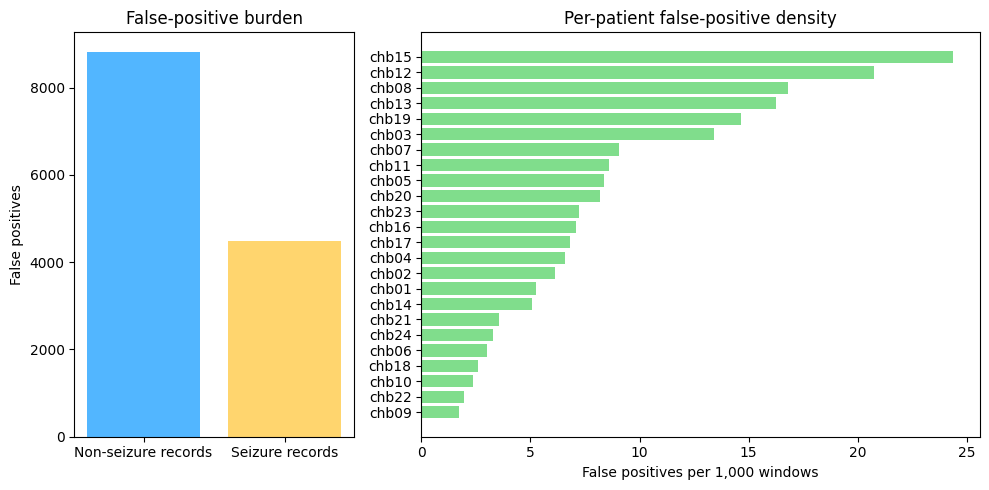

In [23]:

# -----------------------------------
# Colors
# -----------------------------------
GREEN = "#80dd8c"
YELLOW = "#ffd56e"
BLUE = "#52b6ff"

# -----------------------------------
# False-positive burden
# -----------------------------------
segments = segments.copy()
segments["has_seizure"] = segments["n_seizure_windows"] > 0

fp_burden = (
    segments
    .groupby("has_seizure")["fp"]
    .sum()
    .rename({
        True: "Seizure records",
        False: "Non-seizure records"
    })
)

# -----------------------------------
# False-positive density
# -----------------------------------
fp_density = (
    segments
    .groupby("patient")
    .agg(
        fp=("fp", "sum"),
        n_windows=("n_windows", "sum")
    )
)

fp_density["fp_per_1000_windows"] = (
    fp_density["fp"] / fp_density["n_windows"] * 1000
)

# Order from lowest to highest
fp_density = fp_density.sort_values("fp_per_1000_windows")

# -----------------------------------
# Plot
# -----------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [1, 2]}
)

# Left: False-positive burden
colors = [
    YELLOW if label == "Seizure records" else BLUE
    for label in fp_burden.index
]

axes[0].bar(
    fp_burden.index,
    fp_burden.values,
    color=colors
)

axes[0].set_ylabel("False positives")
axes[0].set_title("False-positive burden")

# Right: Per-patient false-positive density
axes[1].barh(
    fp_density.index,
    fp_density["fp_per_1000_windows"],
    color=GREEN
)

axes[1].set_xlabel("False positives per 1,000 windows")
axes[1].set_title("Per-patient false-positive density")

plt.tight_layout()
plt.show()

In [24]:

GREEN = "#0fe071"
YELLOW = "#f4c542"
BLUE = "#4f81bd"


## 1.2 Sensitivity vs. Precision

patient  recs  sz_recs  prevalence   auc    ap  sensitivity  precision    f1  fp_per_1k
  chb01    42        7        0.31 0.949 0.547        0.728      0.300 0.425        5.2
  chb02    36        3        0.11 0.745 0.180        0.286      0.047 0.081        6.1
  chb03    38        7        0.23 0.903 0.207        0.325      0.054 0.092       13.4
  chb04    42        3        0.05 0.894 0.190        0.243      0.019 0.035        6.6
  chb05    39        5        0.31 0.954 0.660        0.616      0.185 0.285        8.4
  chb06    18        7        0.06 0.764 0.175        0.344      0.060 0.102        3.0
  chb07    19        3        0.12 0.767 0.157        0.253      0.033 0.058        9.1
  chb08    20        5        1.22 0.843 0.509        0.450      0.245 0.317       16.8
  chb09    19        3        0.09 0.955 0.555        0.505      0.215 0.301        1.7
  chb10    25        7        0.22 0.955 0.612        0.588      0.350 0.439        2.4
  chb11    35        3        0.

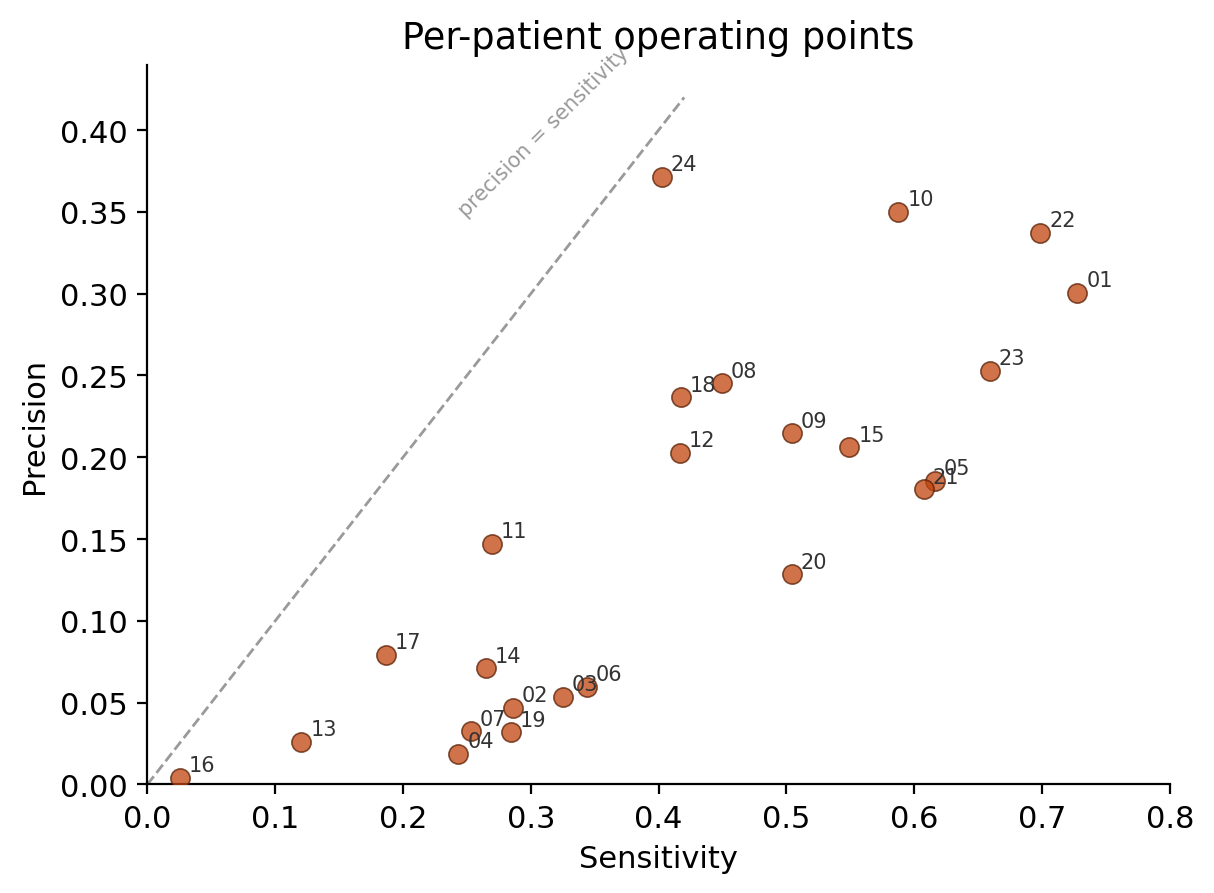

In [25]:

"""
Per-patient segment-level results: Table 2 + Figure 2 (sensitivity vs precision).
 
Input : RECORD_LEVEL_SEGMENT_RESULTS.csv
        (one row per record; columns include patient, record, n_windows,
         n_seizure_windows, roc_auc, ap, tp, fp, fn)
Output: per_patient_table.csv  and  figure2_sens_vs_prec.png
"""
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
CSV = "RESULTS/RECORD_LEVEL_SEGMENT_RESULTS.csv"
 
# ---------------------------------------------------------------------------
# 1. Per-patient metrics (Table 2)
#    Metrics are POOLED within each patient: sum the TP/FP/FN counts across
#    all of that patient's records, then compute the rates from the totals.
#    (This is a micro-average per patient, not the mean of per-record rates.)
# ---------------------------------------------------------------------------
df = pd.read_csv(CSV)
 
g = (df.groupby("patient")
       .agg(recs=("record", "count"),                              # total records
            sz_recs=("n_seizure_windows", lambda x: (x > 0).sum()),# seizure records
            win=("n_windows", "sum"),                              # total windows
            sz=("n_seizure_windows", "sum"),                       # seizure windows
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
            auc=("roc_auc", "mean"),                               # mean over records
            ap=("ap", "mean"))
       .reset_index())
 
g["sensitivity"] = g.tp / (g.tp + g.fn)          # recall
g["precision"]   = g.tp / (g.tp + g.fp)
g["f1"]          = 2 * g.precision * g.sensitivity / (g.precision + g.sensitivity)
g["prevalence"]  = g.sz / g.win                  # fraction of windows that are seizure
g["fp_per_1k"]   = g.fp / g.win * 1000           # false-positive density
 
# Table 2, ordered and rounded for reporting
table = g[["patient", "recs", "sz_recs", "prevalence", "auc", "ap",
           "sensitivity", "precision", "f1", "fp_per_1k"]].copy()
table["prevalence"] = table["prevalence"] * 100  # as a percentage
table = table.round({"prevalence": 2, "auc": 3, "ap": 3,
                     "sensitivity": 3, "precision": 3, "f1": 3, "fp_per_1k": 1})
table.to_csv("per_patient_table.csv", index=False)
print(table.to_string(index=False))
 
# ---------------------------------------------------------------------------
# 2. Correlations reported in the text
#    Spearman = Pearson correlation of the ranks (no scipy needed).
# ---------------------------------------------------------------------------
def pearson(a, b):
    return np.corrcoef(a, b)[0, 1]
 
def spearman(a, b):
    ra, rb = pd.Series(a).rank(), pd.Series(b).rank()
    return np.corrcoef(ra, rb)[0, 1]
 
print(f"\nprecision ~ sensitivity : Pearson {pearson(g.precision, g.sensitivity):.3f}, "
      f"Spearman {spearman(g.precision, g.sensitivity):.3f}")
print(f"precision ~ prevalence  : Pearson {pearson(g.precision, g.prevalence):.3f}, "
      f"Spearman {spearman(g.precision, g.prevalence):.3f}")
 
# ---------------------------------------------------------------------------
# 3. Figure 2 : per-patient operating points (sensitivity vs precision)
# ---------------------------------------------------------------------------
plt.rcParams.update({"font.size": 11, "font.family": "DejaVu Sans",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 200})
ORANGE, GREY = "#c1440e", "#9a9a9a"
 
fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.plot([0, 0.42], [0, 0.42], ls="--", color=GREY, lw=1, zorder=1)      # precision = sensitivity
ax.text(0.31, 0.345, "precision = sensitivity", rotation=45,
        fontsize=7.5, color=GREY, ha="center", va="bottom")
ax.scatter(g.sensitivity, g.precision, s=48, color=ORANGE, alpha=0.75,
           edgecolor="#5a2004", linewidth=0.6, zorder=3)
for x, y, name in zip(g.sensitivity, g.precision, g.patient):
    ax.annotate(name.replace("chb", ""), (x, y), fontsize=7.5, color="#333",
                xytext=(x + 0.007, y + 0.004), textcoords="data")
 
ax.set_xlabel("Sensitivity")
ax.set_ylabel("Precision")
ax.set_title("Per-patient operating points")
ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.44)
fig.tight_layout()
fig.savefig("figure2_sens_vs_prec.png")
print("\nSaved figure2_sens_vs_prec.png and per_patient_table.csv")

## 134 ROC AUC and AP vs. F1

In [30]:
patient_auc = (
    segments
    .groupby("patient")
    .agg(
        roc_auc=("roc_auc", "median"),
        f1=("seg_f1", "median")
    )
    .reset_index()
)

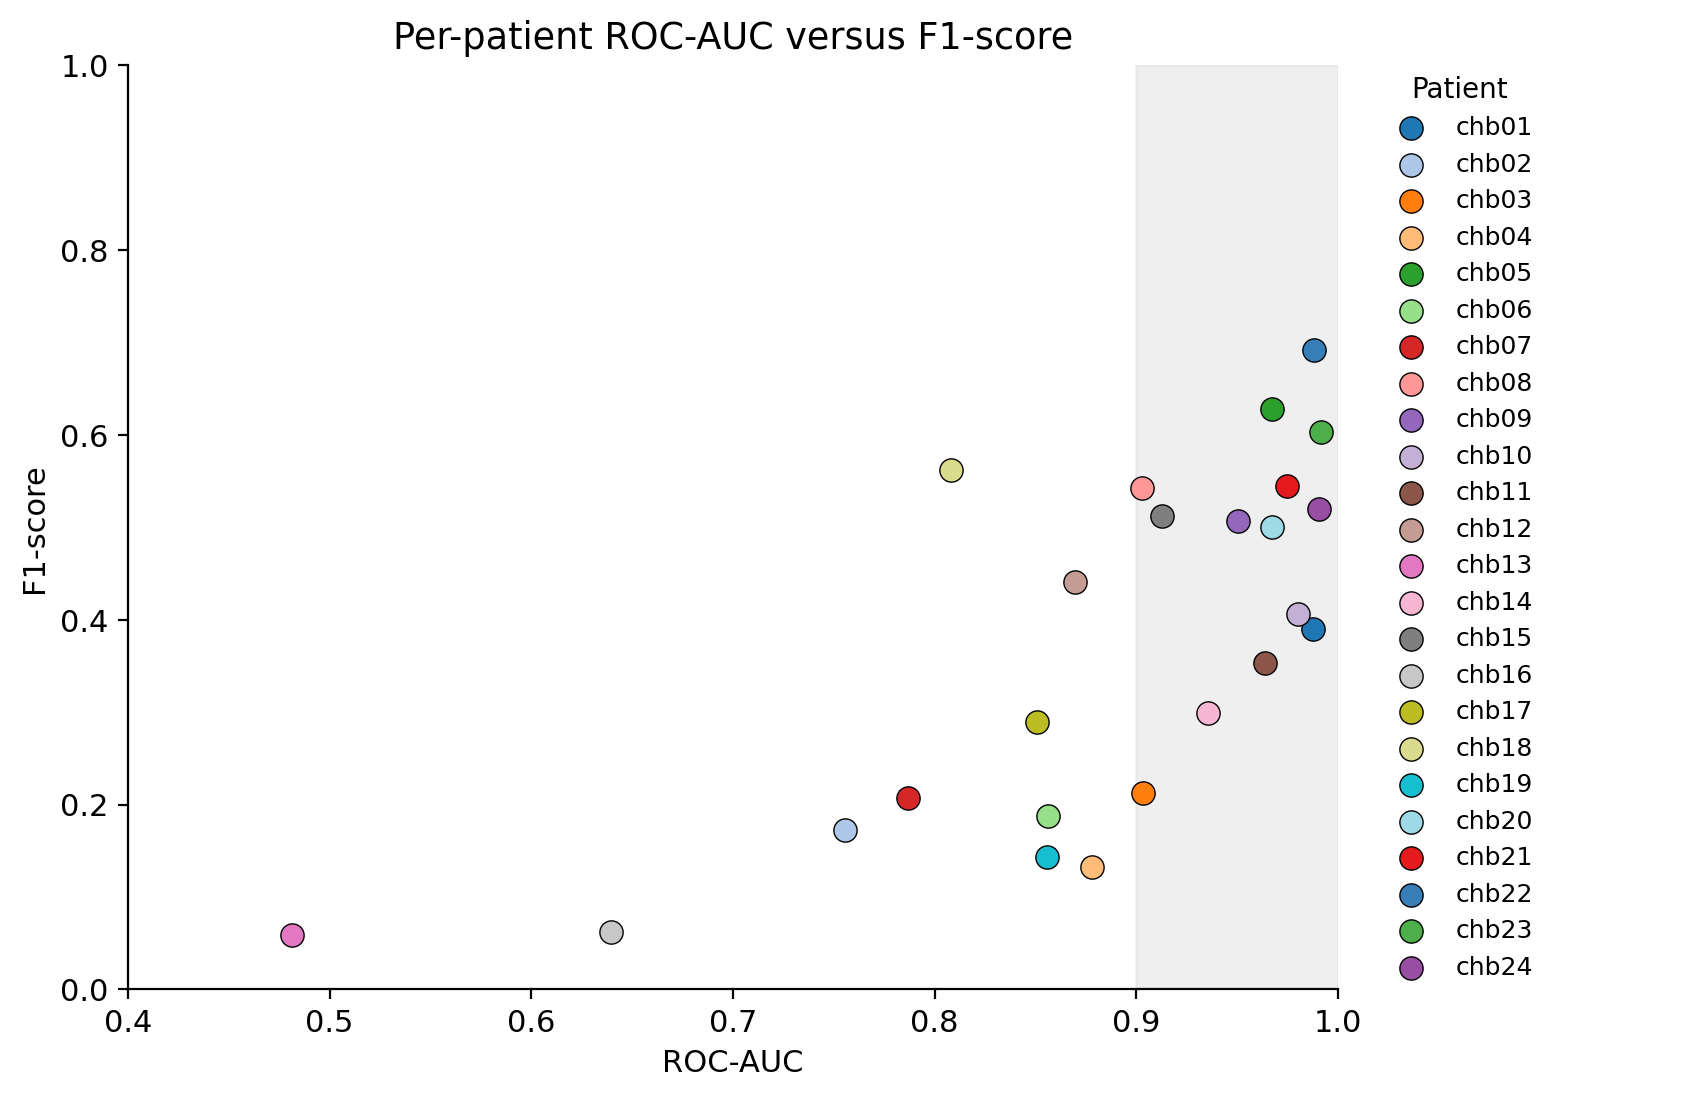

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by patient (optional)
patient_auc = patient_auc.sort_values("patient").reset_index(drop=True)

# Create figure with two columns:
# left = scatter plot, right = legend
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[4, 1], wspace=0.05)

ax = fig.add_subplot(gs[0, 0])
ax_leg = fig.add_subplot(gs[0, 1])

# -----------------------------------
# Shade ROC-AUC >= 0.90
# -----------------------------------
ax.axvspan(
    0.90,
    1.00,
    color="lightgray",
    alpha=0.35,
    zorder=0
)

# -----------------------------------
# One colour per patient
# -----------------------------------
colors = (
    list(plt.cm.tab20.colors)
    + list(plt.cm.Set1.colors)
    + list(plt.cm.Dark2.colors)
)

colors = colors[:len(patient_auc)]

for color, (_, row) in zip(colors, patient_auc.iterrows()):
    ax.scatter(
        row["roc_auc"],
        row["f1"],
        s=70,
        color=color,
        edgecolor="black",
        linewidth=0.5,
        label=row["patient"]
    )

# -----------------------------------
# Main plot formatting
# -----------------------------------
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("F1-score")
ax.set_title("Per-patient ROC-AUC versus F1-score")

ax.set_xlim(0.4, 1.0)
ax.set_ylim(0, 1)

# -----------------------------------
# Legend panel
# -----------------------------------
handles, labels = ax.get_legend_handles_labels()

ax_leg.legend(
    handles,
    labels,
    title="Patient",
    loc="center left",
    frameon=False,
    fontsize=9,
    title_fontsize=10,
    borderaxespad=0
)

ax_leg.axis("off")

plt.show()

KeyError: 'ap'

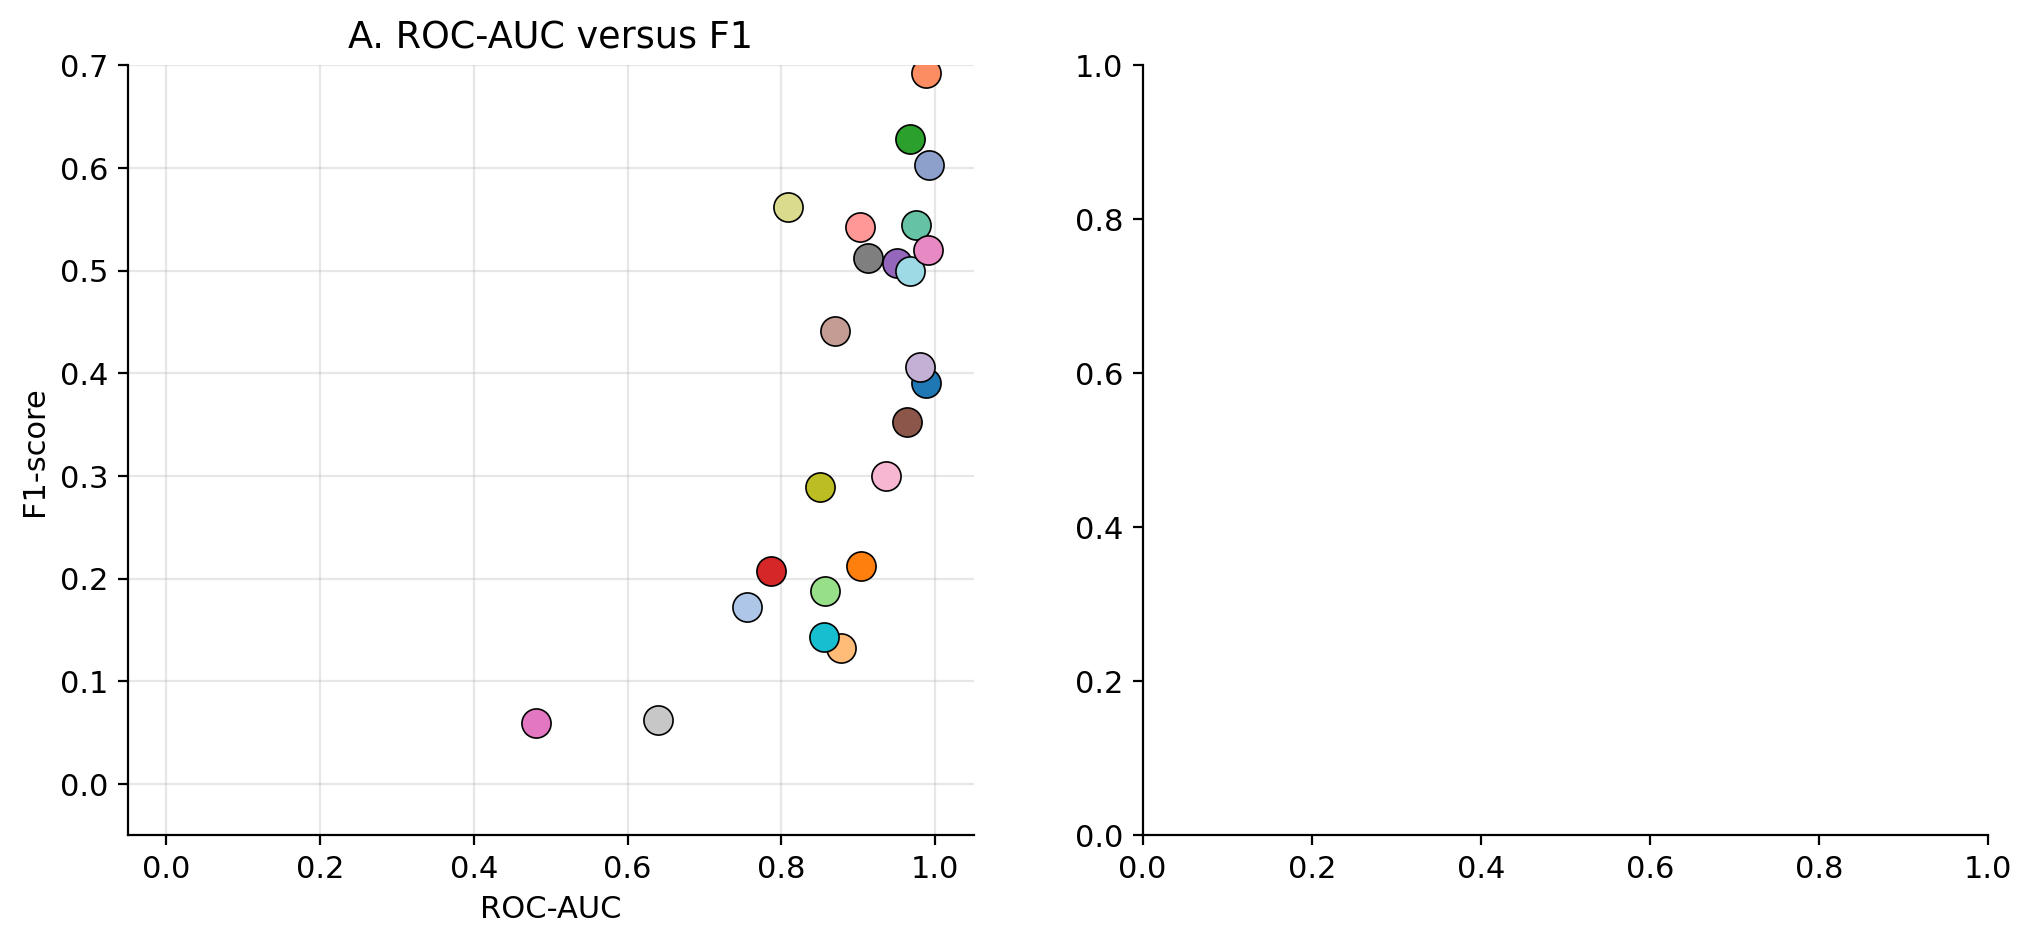

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Prepare data
# -----------------------------
patient = (
    patient_auc
    .drop_duplicates(subset="patient")
    .sort_values("patient")
    .reset_index(drop=True)
)

# -----------------------------
# One colour per patient
# -----------------------------
colors = (
    list(plt.cm.tab20.colors)
    + list(plt.cm.Set2.colors)
    + list(plt.cm.Dark2.colors)
)

colors = colors[:len(patient)]

patient_colors = {
    p: c for p, c in zip(patient["patient"], colors)
}

# -----------------------------
# Figure layout
# -----------------------------
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharey=False      # <-- don't share while adjusting limits
)

ticks = np.arange(0, 1.01, 0.2)

# =====================================================
# Left: ROC-AUC vs F1
# =====================================================

# ax1.axvspan(
#     0.90,
#     1.00,
#     color="lightgray",
#     alpha=0.30,
#     zorder=0
# )

for _, row in patient.iterrows():

    ax1.scatter(
        row["roc_auc"],
        row["f1"],
        s=110,
        color=patient_colors[row["patient"]],
        edgecolor="black",
        linewidth=0.6,
        zorder=2
    )

    # ax1.text(
    #     row["roc_auc"] + 0.01,
    #     row["f1"] + 0.01,
    #     row["patient"],
    #     fontsize=8
    # )

ax1.set_title("A. ROC-AUC versus F1")
ax1.set_xlabel("ROC-AUC")
ax1.set_ylabel("F1-score")

# ---- YOUR LIMITS ----
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 0.70)

ax1.set_xticks(ticks)
ax1.set_yticks(np.arange(0, 0.71, 0.1))

ax1.grid(alpha=0.3)

# =====================================================
# Right: AP vs F1
# =====================================================

for _, row in patient.iterrows():

    ax2.scatter(
        row["ap"],
        row["f1"],
        s=110,
        color=patient_colors[row["patient"]],
        edgecolor="black",
        linewidth=0.6,
        zorder=2
    )

    # ax2.text(
    #     row["ap"] + 0.01,
    #     row["f1"] + 0.01,
    #     row["patient"],
    #     fontsize=8
    # )

ax2.set_title("B. Average Precision versus F1")
ax2.set_xlabel("Average Precision")

# ---- SAME LIMITS ----
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 0.70)

ax2.set_xticks(ticks)
ax2.set_yticks(np.arange(0, 0.71, 0.1))

ax2.grid(alpha=0.3)

plt.tight_layout()

# Check the limits
print("ax1:", ax1.get_xlim(), ax1.get_ylim())
print("ax2:", ax2.get_xlim(), ax2.get_ylim())
from matplotlib.lines import Line2D

# Create one legend entry per patient
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=p,
        markerfacecolor=patient_colors[p],
        markeredgecolor='black',
        markersize=12
    )
    for p in patient["patient"]
]

# Add the legend to the figure
fig.legend(
    handles=legend_handles,
    title="Patient",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    ncol=1
)

plt.show()

## 1.5 Record level analysis

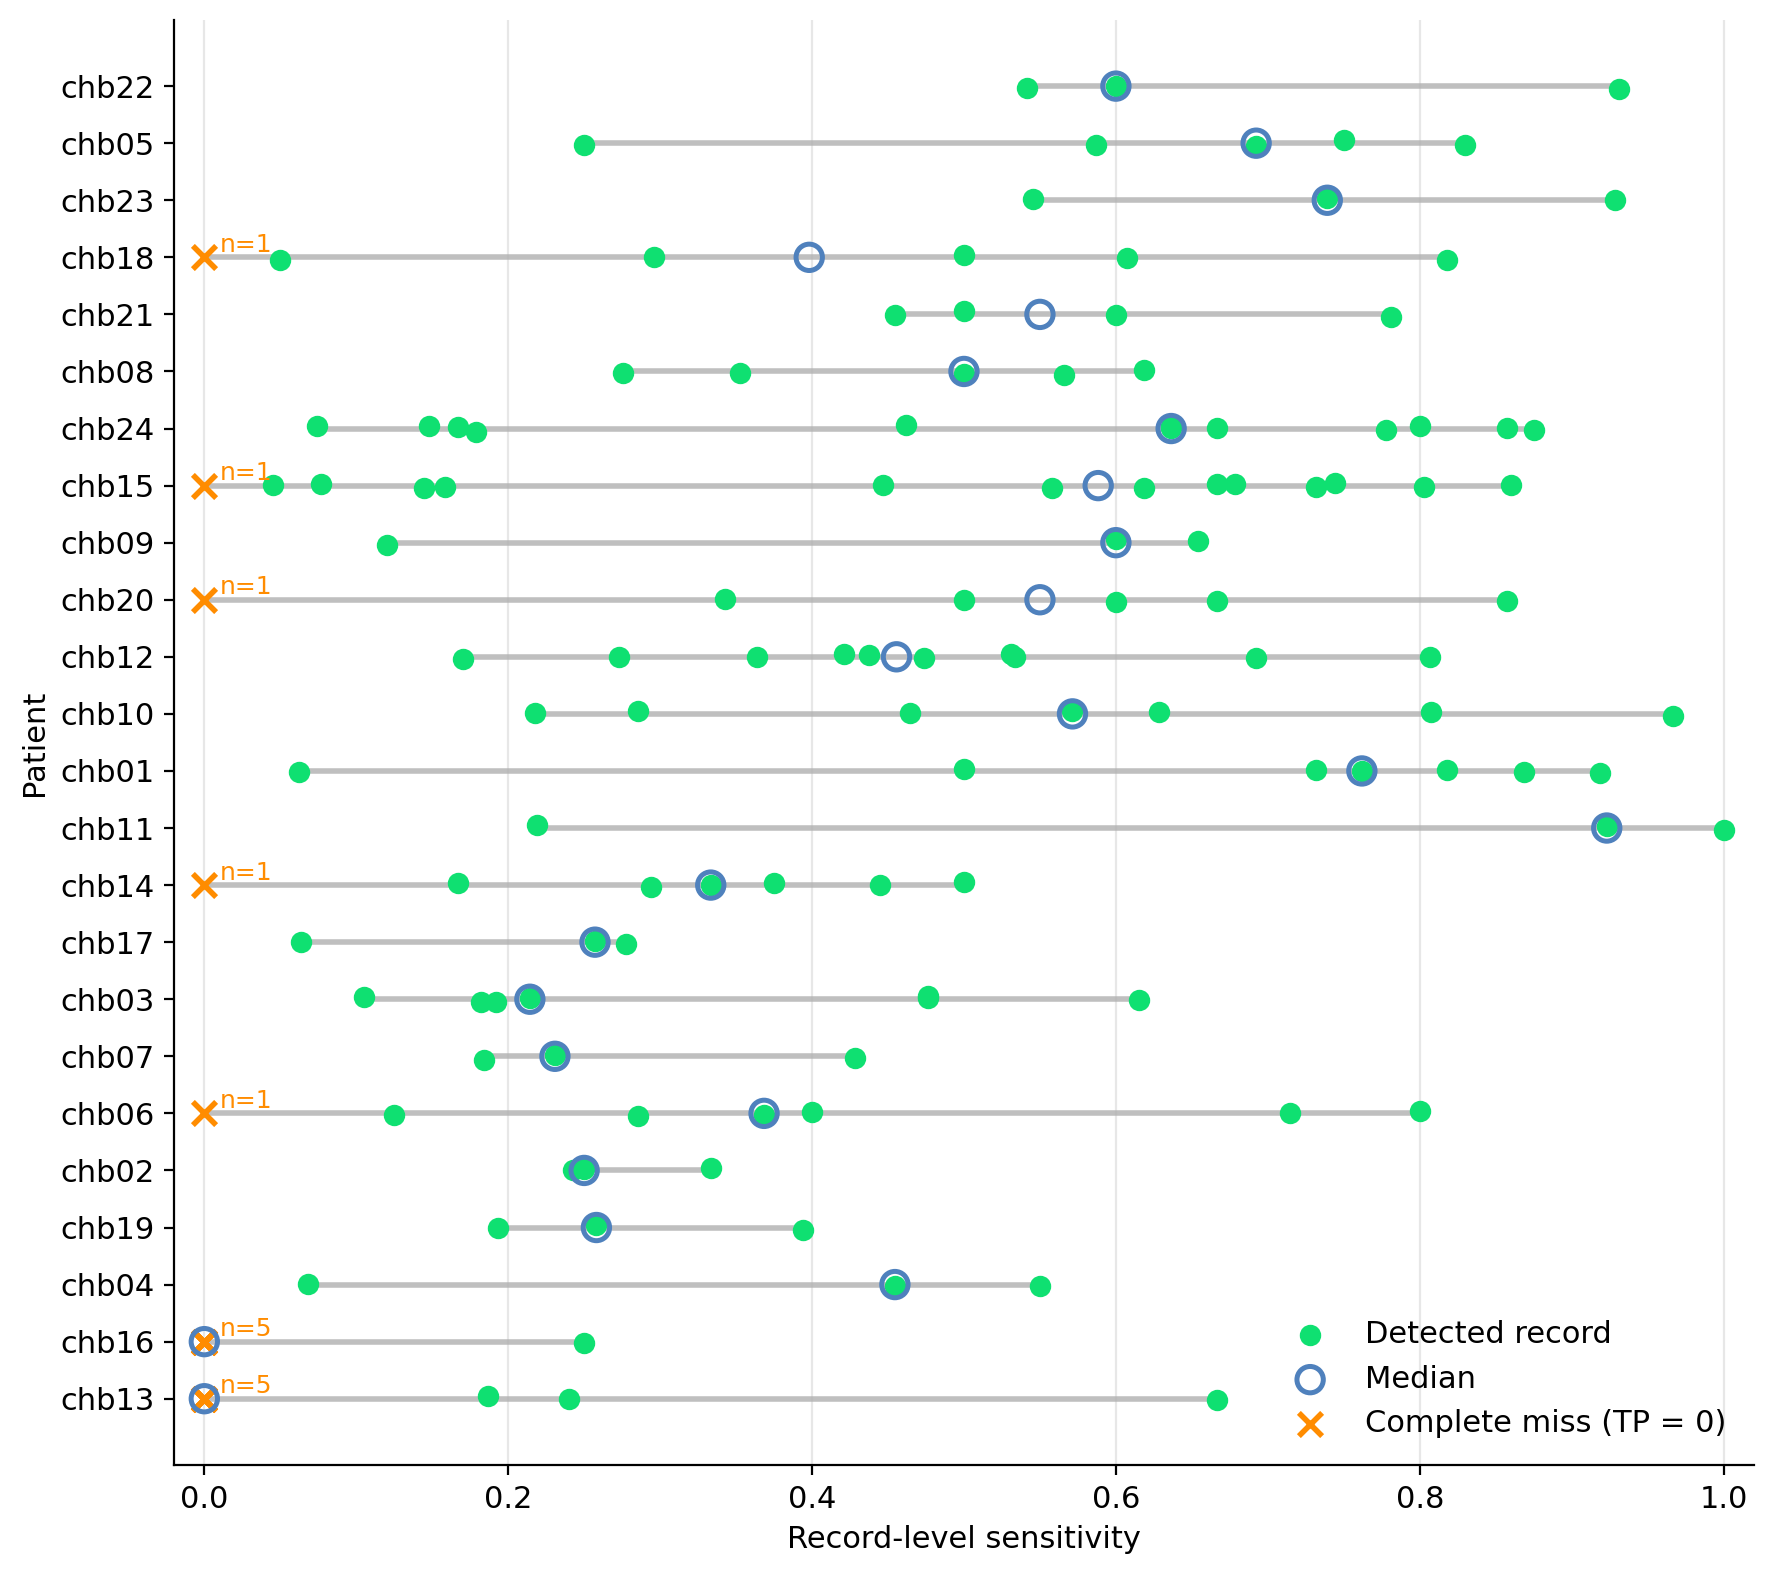

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------------------------------
# Record-level results (seizure-containing records)
# -------------------------------------------------
df = segment_nan.copy()

# Order patients by patient-level F1 (or AP if preferred)
patient_order = (
    segments.groupby("patient")["seg_f1"]
    .median()
    .sort_values(ascending=False)
    .index
)

df["patient"] = pd.Categorical(
    df["patient"],
    categories=patient_order,
    ordered=True
)

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 8))

# Legend control
detected_label_added = False
miss_label_added = False
median_label_added = False

rng = np.random.default_rng(42)

for i, patient in enumerate(patient_order):

    d = df[df["patient"] == patient]

    # Range
    ax.hlines(
        y=i,
        xmin=d["seg_sensitivity"].min(),
        xmax=d["seg_sensitivity"].max(),
        color="0.75",
        lw=2,
        zorder=1,
    )

    # -----------------------------
    # Detected records
    # -----------------------------
    detected = d[d["tp"] > 0]

    # small vertical jitter only for overlapping detected records
    y_detected = i + rng.uniform(-0.06, 0.06, len(detected))

    ax.scatter(
        detected["seg_sensitivity"],
        y_detected,
        color=GREEN,
        s=45,
        label="Detected record" if not detected_label_added else "",
        zorder=3,
    )

    detected_label_added = True

    # -----------------------------
    # Complete misses
    # -----------------------------
    missed = d[d["tp"] == 0]

    if len(missed) > 0:

        ax.scatter(
            missed["seg_sensitivity"],
            np.full(len(missed), i),
            color="darkorange",
            marker="x",
            s=70,
            linewidths=2,
            label="Complete miss (TP = 0)" if not miss_label_added else "",
            zorder=4,
        )

        miss_label_added = True

        # Number of misses above the marker
        ax.text(
            0.01,
            i - 0.22,
            f"n={len(missed)}",
            va="center",
            ha="left",
            fontsize=9,
            color="darkorange",
            zorder=5,
        )

    # -----------------------------
    # Patient median
    # -----------------------------
    median = d["seg_sensitivity"].median()

    ax.scatter(
        median,
        i,
        s=90,
        facecolors="none",
        edgecolors=BLUE,
        linewidths=1.8,
        label="Median" if not median_label_added else "",
        zorder=5,
    )

    median_label_added = True


# -------------------------------------------------
# Formatting
# -------------------------------------------------
ax.set_xlim(-0.02, 1.02)

ax.set_xlabel("Record-level sensitivity")
ax.set_ylabel("Patient")

ax.set_yticks(range(len(patient_order)))
ax.set_yticklabels(patient_order)

ax.invert_yaxis()

ax.grid(axis="x", alpha=0.3)

ax.legend(
    frameon=False,
    loc="lower right"
)

plt.tight_layout()
plt.show()